# Coupled SMB and glacier-flow initialization histories

This notebook addresses [Issue #19](https://github.com/bradlipovsky/allan-hills-stratigraphy/issues/19): does the ALHIC1901 result depend on imposing the surface-mass-balance seed before the depth-dependent glacier shear?

The current unified model is often summarized too strongly as “SMB first, flow later.” In fact, its 200 yr surface stage already advects material at a **uniform horizontal speed** equal to the slab surface speed. What is absent during seed formation is the slab's **depth-dependent** horizontal shear. Here the fitted Glen $n=3$ geometry, transfer, shortening, and age law are held fixed while only the onset schedule is changed. Each history uses one time-dependent particle equation during the surface stage; phase and post-transfer shear duration are then either held fixed or, in a second comparison, refitted.

## Data and fixed target

The target is unchanged from the unified $n=3$ notebook: all 88 ALHIC1901 $^{40}$Ar$_{ATM}$ ages, their relative errors, and the three independently identified old-age peaks between 141 and 155 m.

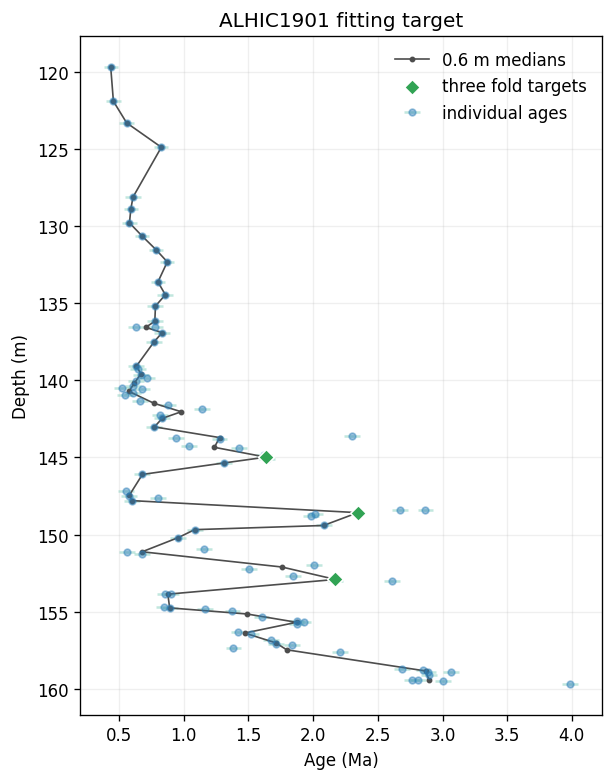

In [1]:
import logging
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message="Unable to import recommended hash.*")
warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from IPython.display import Markdown, display
from scipy.optimize import differential_evolution
from scipy.signal import find_peaks
import firedrake as fd

logging.getLogger("tsfc").setLevel(logging.ERROR)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})

data_path = Path("data/shackleton.pnas.2502681122.sd01.xlsx")
if not data_path.exists():
    data_path = Path("../data/shackleton.pnas.2502681122.sd01.xlsx")
workbook = openpyxl.load_workbook(data_path, read_only=True, data_only=True)
sheet = workbook["Ar and Water isotopes"]
rows = [
    (float(row[1]), float(row[8]), float(row[9]), float(row[10]))
    for row in sheet.iter_rows(min_row=3, values_only=True)
    if row[0] == "ALHIC1901" and isinstance(row[8], (int, float))
]
observations = np.asarray(sorted(rows), dtype=float)
depth, age, relative_error, absolute_error = observations.T

BIN_WIDTH = 0.6
bin_edges = np.arange(119.5, 160.1 + BIN_WIDTH, BIN_WIDTH)
bin_depth, bin_age = [], []
for left, right in zip(bin_edges[:-1], bin_edges[1:]):
    selected = (depth >= left) & (depth < right)
    if np.any(selected):
        bin_depth.append(np.mean(depth[selected]))
        bin_age.append(np.median(age[selected]))
bin_depth, bin_age = np.asarray(bin_depth), np.asarray(bin_age)
fold_bins = (bin_depth >= 141.0) & (bin_depth <= 155.0)
peak_indices = find_peaks(bin_age[fold_bins], prominence=0.3, distance=3)[0]
observed_peak_depths = bin_depth[fold_bins][peak_indices]
observed_peak_ages = bin_age[fold_bins][peak_indices]
assert len(observed_peak_depths) == 3

fig, ax = plt.subplots(figsize=(5.0, 6.4), constrained_layout=True)
ax.errorbar(age, depth, xerr=relative_error, fmt="o", ms=4, alpha=0.48,
            color="#2c7fb8", ecolor="#7fcdbb", label="individual ages")
ax.plot(bin_age, bin_depth, ".-", color="0.3", lw=1, ms=5, label="0.6 m medians")
ax.scatter(observed_peak_ages, observed_peak_depths, marker="D", s=45,
           color="#31a354", edgecolor="white", zorder=5, label="three fold targets")
ax.invert_yaxis()
ax.set(xlabel="Age (Ma)", ylabel="Depth (m)", title="ALHIC1901 fitting target")
ax.legend(frameon=False)
plt.show()

## Full-Stokes end-member fields

The two end-member fields are the same factor-two mesh pair used in the unified $n=3$ notebook. One is a periodic full-Stokes surface cell driven by sinusoidal surface-normal velocity; the other is a gravity-driven, no-slip full-Stokes slab. Both use the full symmetric velocity gradient, incompressibility, and Glen $n=3$ viscosity.

During the surface episode we schedule their velocities in the Lagrangian equation

$$
\dot x=f(t)u_s(H-y)+b\,g(t)\hat u(x/\lambda,y/\lambda),\qquad
\dot y=b\,g(t)\hat v(x/\lambda,y/\lambda),
$$

where $y$ is depth below the surface. The “current” baseline replaces $u_s(H-y)$ with the constant surface speed, exactly as in the existing notebook. This is a kinematic composition of two independently solved nonlinear full-Stokes fields, not a new nonlinear Stokes solve for their sum. It preserves the prescribed surface-to-bed transfer; zero-mean SMB plus parallel slab flow cannot dynamically bury the packet.

In [2]:
L, H = 2_000.0, 160.0
RHO, G, ALPHA = 917.0, 9.81, 0.03
GLEN_N = 3.0
REFERENCE_MU = 2.5e8
EPS_REG = 1e-10
DRIVING = RHO * G * np.sin(ALPHA)
SURFACE_SPEED = DRIVING * H**2 / (2 * REFERENCE_MU)
SOFTNESS = SURFACE_SPEED * (GLEN_N + 1) / (2 * DRIVING**GLEN_N * H**(GLEN_N + 1))
UNIT_HEIGHT = 6.0
UNIT_EPS_REG = 1e-3

def analytical_velocity(z):
    return 2 * SOFTNESS * DRIVING**GLEN_N / (GLEN_N + 1) * (
        H**(GLEN_N + 1) - (H - z)**(GLEN_N + 1)
    )

def solve_slab(nx, nz):
    mesh = fd.RectangleMesh(nx, nz, L, H)
    V = fd.VectorFunctionSpace(mesh, "CG", 2)
    Q = fd.FunctionSpace(mesh, "CG", 1)
    mixed = V * Q
    z = fd.SpatialCoordinate(mesh)[1]
    solution = fd.Function(mixed, name=f"slab_n3_{nx}_{nz}")
    u, p = fd.split(solution)
    v, q = fd.TestFunctions(mixed)
    strain = fd.sym(fd.grad(u))
    effective_strain = fd.sqrt(0.5 * fd.inner(strain, strain) + EPS_REG**2)
    viscosity = 0.5 * SOFTNESS**(-1 / GLEN_N) * effective_strain**((1 - GLEN_N) / GLEN_N)
    body = fd.Constant((RHO * G * np.sin(ALPHA), -RHO * G * np.cos(ALPHA)))
    residual = (
        2 * viscosity * fd.inner(strain, fd.sym(fd.grad(v)))
        - p * fd.div(v) - q * fd.div(u) - fd.dot(body, v)
    ) * fd.dx
    side_velocity = fd.as_vector((analytical_velocity(z), 0.0))
    bcs = [
        fd.DirichletBC(mixed.sub(0), side_velocity, 1),
        fd.DirichletBC(mixed.sub(0), side_velocity, 2),
        fd.DirichletBC(mixed.sub(0), fd.Constant((0.0, 0.0)), 3),
    ]
    solution.sub(0).interpolate(side_velocity)
    solution.sub(1).interpolate(RHO * G * np.cos(ALPHA) * (H - z))
    fd.solve(residual == 0, solution, bcs=bcs, solver_parameters={
        "snes_type": "newtonls", "snes_linesearch_type": "bt", "snes_rtol": 1e-9,
        "ksp_type": "preonly", "pc_type": "lu", "pc_factor_mat_solver_type": "mumps",
    })
    velocity, pressure = solution.subfunctions
    heights = np.linspace(0.0, H, 1601)
    points = np.column_stack((np.full_like(heights, L / 2), heights))
    profile = np.asarray(velocity.at(points, tolerance=1e-10))[:, 0]
    divergence = fd.project(fd.div(velocity), Q)
    div_l2 = np.sqrt(float(fd.assemble(divergence**2 * fd.dx)))
    grad_l2 = np.sqrt(float(fd.assemble(fd.inner(fd.grad(velocity), fd.grad(velocity)) * fd.dx)))
    return {"velocity": velocity, "profile": profile, "heights": heights,
            "divergence_ratio": div_l2 / grad_l2, "nx": nx, "nz": nz}

def solve_surface_cell(nx, ny):
    mesh = fd.PeriodicRectangleMesh(nx, ny, 1.0, UNIT_HEIGHT, direction="x")
    V = fd.VectorFunctionSpace(mesh, "CG", 2)
    Q = fd.FunctionSpace(mesh, "CG", 1)
    mixed = V * Q
    x, z = fd.SpatialCoordinate(mesh)
    y = UNIT_HEIGHT - z
    solution = fd.Function(mixed, name=f"surface_n3_{nx}_{ny}")
    u, p = fd.split(solution)
    v, q = fd.TestFunctions(mixed)
    top_velocity = fd.as_vector((0.0, -fd.sin(2 * np.pi * x)))
    bcs = [
        fd.DirichletBC(mixed.sub(0), fd.Constant((0.0, 0.0)), 1),
        fd.DirichletBC(mixed.sub(0), top_velocity, 2),
    ]
    k = 2 * np.pi
    solution.sub(0).interpolate(fd.as_vector((
        -k * y * fd.exp(-k * y) * fd.cos(k * x),
        -(1 + k * y) * fd.exp(-k * y) * fd.sin(k * x),
    )))
    solution.sub(1).assign(0.0)
    nullspace = fd.MixedVectorSpaceBasis(
        mixed, [mixed.sub(0), fd.VectorSpaceBasis(constant=True)]
    )
    for exponent in (1.0, 1.5, 2.0, 2.5, 3.0):
        strain = fd.sym(fd.grad(u))
        effective_strain = fd.sqrt(0.5 * fd.inner(strain, strain) + UNIT_EPS_REG**2)
        viscosity = 0.5 * effective_strain**((1 - exponent) / exponent)
        residual = (
            2 * viscosity * fd.inner(strain, fd.sym(fd.grad(v)))
            - p * fd.div(v) - q * fd.div(u)
        ) * fd.dx
        fd.solve(
            residual == 0, solution, bcs=bcs, nullspace=nullspace,
            transpose_nullspace=nullspace,
            solver_parameters={
                "snes_type": "newtonls", "snes_linesearch_type": "bt", "snes_rtol": 1e-8,
                "ksp_type": "preonly", "pc_type": "lu",
                "pc_factor_mat_solver_type": "mumps",
                "mat_mumps_icntl_24": 1, "mat_mumps_icntl_13": 1,
            },
        )
    velocity, pressure = solution.subfunctions
    divergence = fd.project(fd.div(velocity), Q)
    div_l2 = np.sqrt(float(fd.assemble(divergence**2 * fd.dx)))
    grad_l2 = np.sqrt(float(fd.assemble(fd.inner(fd.grad(velocity), fd.grad(velocity)) * fd.dx)))
    return {"mesh": mesh, "velocity": velocity, "pressure": pressure,
            "divergence_ratio": div_l2 / grad_l2, "nx": nx, "ny": ny}

coarse_slab = solve_slab(80, 16)
fine_slab = solve_slab(160, 32)
coarse_surface = solve_surface_cell(16, 96)
fine_surface = solve_surface_cell(32, 192)

unit_x = np.linspace(0.0, 1.0, 129, endpoint=False)
unit_y = np.linspace(0.0, UNIT_HEIGHT, 193)
def velocity_grid(result):
    X, Y = np.meshgrid(unit_x, unit_y)
    points = np.column_stack((X.ravel(), UNIT_HEIGHT - Y.ravel()))
    values = np.asarray(result["velocity"].at(points, tolerance=1e-9)).reshape(
        len(unit_y), len(unit_x), 2
    )
    values[:, :, 1] *= -1.0
    return values

coarse_unit_grid = velocity_grid(coarse_surface)
fine_unit_grid = velocity_grid(fine_surface)
surface_mesh_difference = np.max(np.abs(fine_unit_grid - coarse_unit_grid))

def unit_velocity(xhat, yhat, field=fine_unit_grid):
    xhat, yhat = np.broadcast_arrays(np.asarray(xhat, dtype=float), np.asarray(yhat, dtype=float))
    x_periodic = np.mod(xhat, 1.0)
    i_float = x_periodic * len(unit_x)
    i0 = np.floor(i_float).astype(int) % len(unit_x)
    i1 = (i0 + 1) % len(unit_x)
    fx = i_float - np.floor(i_float)
    y_clipped = np.clip(yhat, unit_y[0], unit_y[-1])
    j_float = (y_clipped - unit_y[0]) / (unit_y[1] - unit_y[0])
    j0 = np.minimum(np.floor(j_float).astype(int), len(unit_y) - 2)
    j1 = j0 + 1
    fy = np.minimum(j_float - j0, 1.0)
    values = (
        (1 - fx)[..., None] * (1 - fy)[..., None] * field[j0, i0]
        + fx[..., None] * (1 - fy)[..., None] * field[j0, i1]
        + (1 - fx)[..., None] * fy[..., None] * field[j1, i0]
        + fx[..., None] * fy[..., None] * field[j1, i1]
    )
    outside = (yhat < 0.0) | (yhat > UNIT_HEIGHT)
    return np.where(outside[..., None], 0.0, values)

firedrake:WARNING No comm specified for VectorSpaceBasis, COMM_WORLD assumed


firedrake:WARNING No comm specified for VectorSpaceBasis, COMM_WORLD assumed


## Initialization histories

All histories retain the selected $\lambda=60$ m and total signed SMB impulse $b\int g\,dt=20$ m. The seven cases isolate the missing background shear, onset order, and ramp shape:

1. exact current uniform-drift baseline;
2. SMB with no background advection;
3. depth-dependent slab flow active throughout a 200 yr top-hat pulse;
4. 10 kyr of slab flow before that pulse;
5. an impulse-matched 400 yr smooth pulse with slab flow throughout;
6. the same smooth pulse with slab flow ramped up jointly; and
7. a weaker 2 kyr pulse, again impulse matched.

The flow-first delay is a control: horizontal layers cannot change during a delay with $w=0$, and the $n=3$ velocity varies by only $(19.04/160)^4\simeq2\times10^{-4}$ across the fitted surface packet. A negligible result is therefore a prediction, not a numerical failure.

In [3]:
WAVELENGTH = 60.0
SMB_IMPULSE = 20.0
FIXED_COMPRESSION = 0.8678
FIXED_SHEAR_KYR = 47.68
FIXED_PACKET_TOP = 19.04
FIXED_PHASE = 6.024
FIXED_YOUNG_AGE = 0.7331
FIXED_AGE_SCALE = 31.65
FIXED_AGE_POWER = 0.9506

histories = [
    {"name": "current uniform drift", "short": "current", "duration": 200.0,
     "event_start": 0.0, "pulse": "top-hat", "background": "uniform", "b": 0.10,
     "color": "#111111"},
    {"name": "SMB before background flow", "short": "SMB only", "duration": 200.0,
     "event_start": 0.0, "pulse": "top-hat", "background": "none", "b": 0.10,
     "color": "#d95f02"},
    {"name": "depth-dependent flow throughout", "short": "flow throughout", "duration": 200.0,
     "event_start": 0.0, "pulse": "top-hat", "background": "slab", "b": 0.10,
     "color": "#1b9e77"},
    {"name": "10 kyr flow first", "short": "flow first", "duration": 10_200.0,
     "event_start": 10_000.0, "pulse": "top-hat", "background": "slab", "b": 0.10,
     "color": "#7570b3"},
    {"name": "smooth SMB, flow throughout", "short": "smooth SMB", "duration": 400.0,
     "event_start": 0.0, "pulse": "smooth", "background": "slab", "b": 0.10,
     "color": "#e7298a"},
    {"name": "joint smooth ramp", "short": "joint ramp", "duration": 400.0,
     "event_start": 0.0, "pulse": "smooth", "background": "joint-ramp", "b": 0.10,
     "color": "#66a61e"},
    {"name": "weak 2 kyr pulse", "short": "weak long", "duration": 2_000.0,
     "event_start": 0.0, "pulse": "smooth", "background": "slab", "b": 0.02,
     "color": "#e6ab02"},
]

map_phase = np.linspace(0.0, 1.0, 257, endpoint=False)
map_depth = np.linspace(0.0, 85.0, 341)

def forcing(case, time):
    time = np.asarray(time, dtype=float)
    pulse_time = time - case["event_start"]
    pulse_duration = case["duration"] - case["event_start"]
    in_pulse = (pulse_time >= 0.0) & (pulse_time <= pulse_duration)
    if case["pulse"] == "top-hat":
        smb_factor = in_pulse.astype(float)
    else:
        smb_factor = np.where(
            in_pulse, np.sin(np.pi * pulse_time / pulse_duration)**2, 0.0
        )
    if case["background"] == "none":
        flow_factor = np.zeros_like(time)
    elif case["background"] == "joint-ramp":
        flow_factor = np.where(
            in_pulse, 0.5 * (1 - np.cos(np.pi * pulse_time / pulse_duration)),
            (time > case["duration"]).astype(float),
        )
    else:
        flow_factor = np.ones_like(time)
    return flow_factor, smb_factor

def background_velocity(depths, case, profile):
    if case["background"] == "none":
        return np.zeros_like(depths)
    if case["background"] == "uniform":
        return np.full_like(depths, SURFACE_SPEED)
    heights = np.clip(H - depths, 0.0, H)
    return np.interp(heights, fine_slab["heights"], profile)

def backtrack_surface_map(case, end_time=None, max_step=20.0,
                          field=fine_unit_grid, profile=fine_slab["profile"]):
    end_time = case["duration"] if end_time is None else float(end_time)
    X, Y = np.meshgrid(map_phase * WAVELENGTH, map_depth)
    x_position, y_depth = X.copy(), Y.copy()
    steps = max(20, int(np.ceil(end_time / max_step))) if end_time > 0 else 0
    if steps == 0:
        return y_depth
    step = -end_time / steps

    def rhs(time, x_value, y_value):
        flow_factor, smb_factor = forcing(case, time)
        response = unit_velocity(x_value / WAVELENGTH, y_value / WAVELENGTH, field=field)
        horizontal = (
            flow_factor * background_velocity(y_value, case, profile)
            + case["b"] * smb_factor * response[..., 0]
        )
        vertical = case["b"] * smb_factor * response[..., 1]
        return horizontal, vertical

    time = end_time
    for _ in range(steps):
        k1x, k1y = rhs(time, x_position, y_depth)
        k2x, k2y = rhs(
            time + 0.5 * step,
            x_position + 0.5 * step * k1x,
            y_depth + 0.5 * step * k1y,
        )
        k3x, k3y = rhs(
            time + 0.5 * step,
            x_position + 0.5 * step * k2x,
            y_depth + 0.5 * step * k2y,
        )
        k4x, k4y = rhs(
            time + step, x_position + step * k3x, y_depth + step * k3y
        )
        x_position += step * (k1x + 2 * k2x + 2 * k3x + k4x) / 6
        y_depth += step * (k1y + 2 * k2y + 2 * k3y + k4y) / 6
        time += step
    return y_depth

surface_maps = []
for history in histories:
    print(f"Backtracking {history['short']} ...")
    surface_maps.append(backtrack_surface_map(history))

Backtracking current ...


Backtracking SMB only ...


Backtracking flow throughout ...


Backtracking flow first ...


Backtracking smooth SMB ...


Backtracking joint ramp ...


Backtracking weak long ...


In [4]:
def sample_surface_map(material_map, phase, end_depth):
    phase, end_depth = np.broadcast_arrays(np.asarray(phase), np.asarray(end_depth))
    phase_fraction = np.mod(phase / (2 * np.pi), 1.0)
    i_float = phase_fraction * len(map_phase)
    i0 = np.floor(i_float).astype(int) % len(map_phase)
    i1 = (i0 + 1) % len(map_phase)
    fx = i_float - np.floor(i_float)
    y_clipped = np.clip(end_depth, map_depth[0], map_depth[-1])
    j_float = (y_clipped - map_depth[0]) / (map_depth[1] - map_depth[0])
    j0 = np.minimum(np.floor(j_float).astype(int), len(map_depth) - 2)
    j1 = j0 + 1
    fy = np.minimum(j_float - j0, 1.0)
    values = (
        (1 - fx) * (1 - fy) * material_map[j0, i0]
        + fx * (1 - fy) * material_map[j0, i1]
        + (1 - fx) * fy * material_map[j1, i0]
        + fx * fy * material_map[j1, i1]
    )
    outside = (end_depth < map_depth[0]) | (end_depth > map_depth[-1])
    return np.where(outside, np.nan, values)

def model_age(depths, material_map, phase, shear_kyr, profile=fine_slab["profile"]):
    heights = H - np.asarray(depths)
    end_depth = FIXED_PACKET_TOP - heights
    shear_displacement = shear_kyr * 1000 * np.interp(
        heights, fine_slab["heights"], profile
    )
    surface_phase = phase - 2 * np.pi * shear_displacement / (
        FIXED_COMPRESSION * WAVELENGTH
    )
    initial_depth = sample_surface_map(
        material_map, surface_phase, np.maximum(end_depth, 0.0)
    )
    initial_depth = np.where(end_depth <= 0.0, 0.0, initial_depth)
    clipped_depth = np.maximum(initial_depth, 0.0)
    modeled_age = FIXED_YOUNG_AGE + (4.0 - FIXED_YOUNG_AGE) * (
        1 - np.exp(-(clipped_depth / FIXED_AGE_SCALE)**FIXED_AGE_POWER)
    )
    return modeled_age, initial_depth

MODEL_ERROR = 0.15
fold_depth_grid = np.linspace(139.5, 155.5, 801)
fine_curve_depth = np.linspace(119.0, 160.0, 2500)
depth_separation = depth[:, None] - depth[None, :]
sampling_density = np.exp(-0.5 * (depth_separation / 0.45)**2).sum(axis=1)
density_weights = 1.0 / sampling_density
density_weights /= density_weights.mean()

def fit_objective(values, material_map):
    phase, shear_kyr = values
    prediction, _ = model_age(depth, material_map, phase, shear_kyr)
    sigma = np.sqrt(relative_error**2 + MODEL_ERROR**2)
    data_term = np.average(((prediction - age) / sigma)**2, weights=density_weights)
    fold_prediction, _ = model_age(fold_depth_grid, material_map, phase, shear_kyr)
    peaks = find_peaks(fold_prediction, prominence=0.25, distance=90)[0]
    peaks = peaks[(fold_depth_grid[peaks] >= 141.0) & (fold_depth_grid[peaks] <= 155.3)]
    if len(peaks) != 3:
        return data_term + 1000.0 + 500.0 * abs(len(peaks) - 3)
    feature_term = np.mean(((fold_depth_grid[peaks] - observed_peak_depths) / 0.55)**2)
    feature_term += np.mean(((fold_prediction[peaks] - observed_peak_ages) / 0.30)**2)
    return data_term + feature_term

def contact_depths(initial_depths, depths):
    supplied = initial_depths <= 0.0
    crossings = np.flatnonzero(supplied[1:] != supplied[:-1])
    return depths[crossings]

metrics = []
fixed_curves, refit_curves = [], []
for index, (history, material_map) in enumerate(zip(histories, surface_maps)):
    fixed_curve, _ = model_age(
        fine_curve_depth, material_map, FIXED_PHASE, FIXED_SHEAR_KYR
    )
    fit = differential_evolution(
        fit_objective, [(0.0, 2 * np.pi), (25.0, 65.0)], args=(material_map,),
        seed=90 + index, popsize=8, maxiter=100, tol=1e-7, polish=True,
        updating="immediate", workers=1,
    )
    refit_phase, refit_shear = fit.x
    prediction, initial_depth = model_age(depth, material_map, refit_phase, refit_shear)
    curve, curve_initial = model_age(
        fine_curve_depth, material_map, refit_phase, refit_shear
    )
    fold_curve, _ = model_age(
        fold_depth_grid, material_map, refit_phase, refit_shear
    )
    peaks = find_peaks(fold_curve, prominence=0.25, distance=90)[0]
    peaks = peaks[(fold_depth_grid[peaks] >= 141.0) & (fold_depth_grid[peaks] <= 155.3)]
    time_grid = np.linspace(0.0, history["duration"], 4001)
    flow_factor, smb_factor = forcing(history, time_grid)
    active_flow_time = np.trapezoid(flow_factor, time_grid)
    if history["background"] in ("slab", "joint-ramp"):
        surface_velocity_difference = SURFACE_SPEED - np.interp(
            H - FIXED_PACKET_TOP, fine_slab["heights"], fine_slab["profile"]
        )
        surface_shear = active_flow_time * surface_velocity_difference / FIXED_PACKET_TOP
    else:
        surface_shear = 0.0
    post_velocity_difference = np.interp(
        FIXED_PACKET_TOP, fine_slab["heights"], fine_slab["profile"]
    )
    post_shear = refit_shear * 1000 * post_velocity_difference / FIXED_PACKET_TOP
    contacts = contact_depths(curve_initial, fine_curve_depth)
    metrics.append({
        "history": history, "phase": refit_phase, "shear": refit_shear,
        "rmse": np.sqrt(np.mean((prediction - age)**2)),
        "weighted_rmse": np.sqrt(np.average((prediction - age)**2, weights=density_weights)),
        "peaks": fold_depth_grid[peaks], "contacts": contacts,
        "surface_shear": surface_shear, "post_shear": post_shear,
        "first_supply": history["event_start"], "fit": fit,
    })
    fixed_curves.append(fixed_curve)
    refit_curves.append(curve)

joint_index = next(i for i, history in enumerate(histories) if history["short"] == "joint ramp")
joint_history = histories[joint_index]
joint_metric = metrics[joint_index]
joint_half_step_map = backtrack_surface_map(joint_history, max_step=10.0)
joint_coarse_map = backtrack_surface_map(
    joint_history, field=coarse_unit_grid, profile=coarse_slab["profile"]
)
joint_reference_curve = refit_curves[joint_index]
joint_half_step_curve, _ = model_age(
    fine_curve_depth, joint_half_step_map, joint_metric["phase"], joint_metric["shear"]
)
joint_coarse_curve, _ = model_age(
    fine_curve_depth, joint_coarse_map, joint_metric["phase"], joint_metric["shear"],
    profile=coarse_slab["profile"],
)
time_step_difference = np.max(np.abs(joint_reference_curve - joint_half_step_curve))
mesh_difference = np.max(np.abs(joint_reference_curve - joint_coarse_curve))

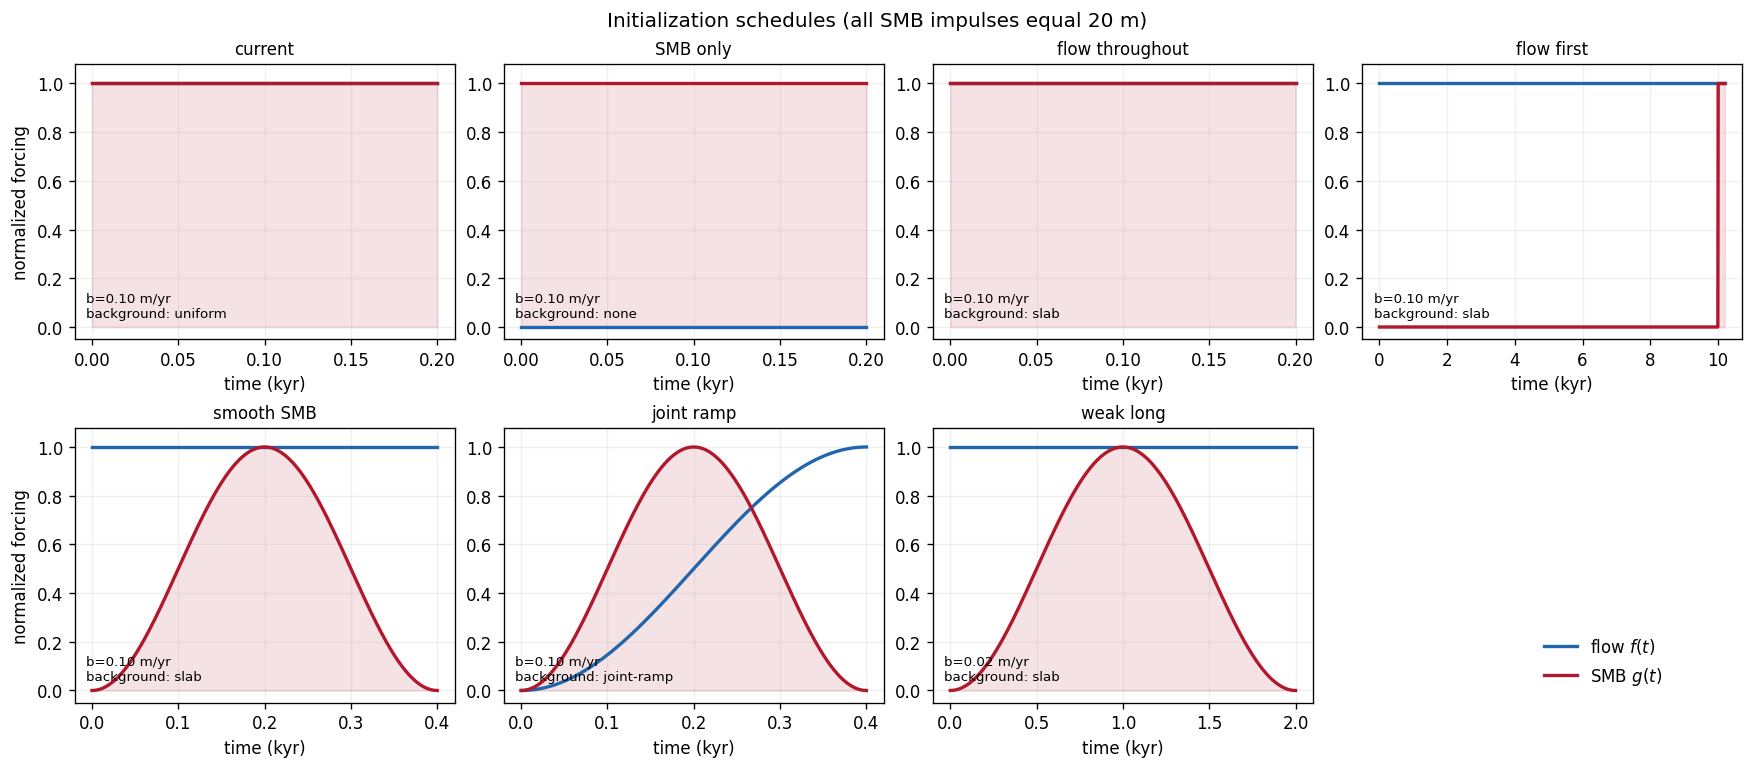

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(14.5, 6.3), constrained_layout=True)
axes = axes.ravel()
for axis, history in zip(axes, histories):
    time = np.linspace(0.0, history["duration"], 1001)
    flow_factor, smb_factor = forcing(history, time)
    axis.plot(time / 1000, flow_factor, color="#2166ac", lw=2, label=r"flow $f(t)$")
    axis.plot(time / 1000, smb_factor, color="#b2182b", lw=2, label=r"SMB $g(t)$")
    axis.fill_between(time / 1000, 0, smb_factor, color="#b2182b", alpha=0.12)
    axis.set_title(history["short"], fontsize=10)
    axis.set(xlabel="time (kyr)", ylim=(-0.05, 1.08))
    axis.text(
        0.03, 0.07,
        f"b={history['b']:.2f} m/yr\nbackground: {history['background']}",
        transform=axis.transAxes, fontsize=8, va="bottom",
    )
axes[0].set_ylabel("normalized forcing")
axes[4].set_ylabel("normalized forcing")
axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.96, 0.08), frameon=False)
fig.suptitle("Initialization schedules (all SMB impulses equal 20 m)")
plt.show()

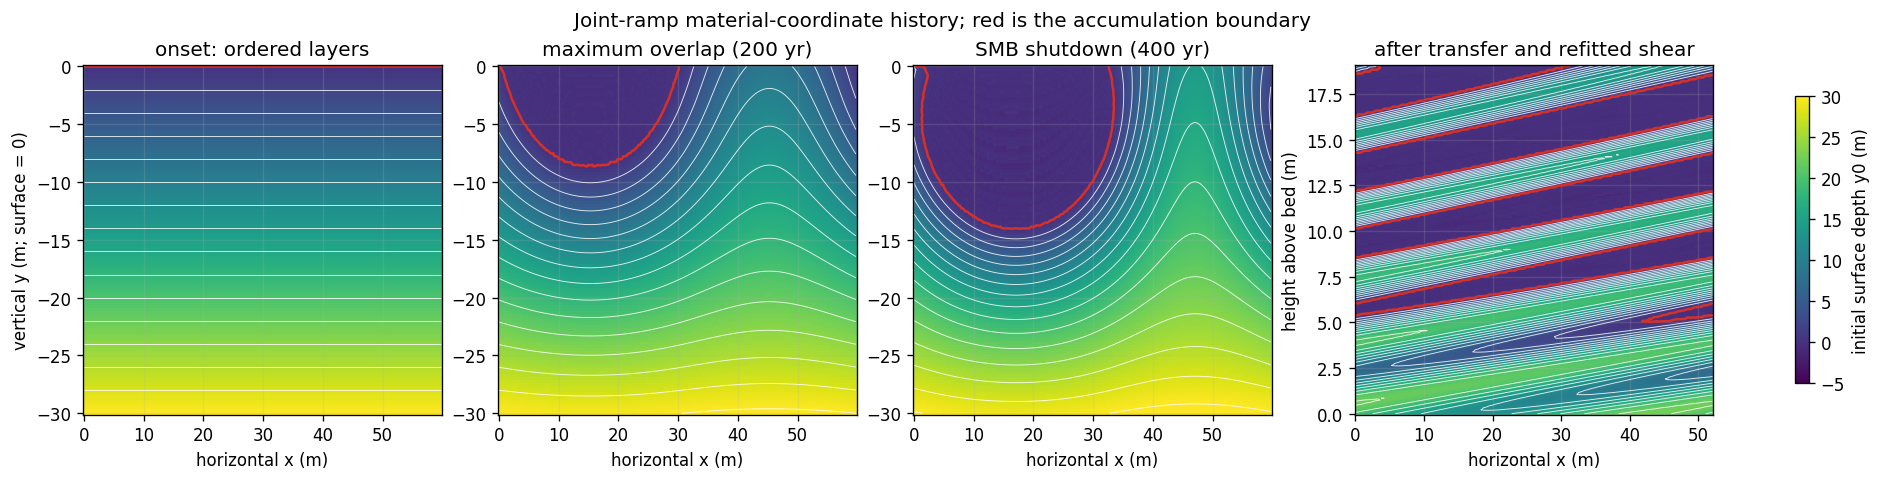

In [6]:
joint_mid_map = backtrack_surface_map(
    joint_history, end_time=joint_history["duration"] / 2
)
initial_map = np.broadcast_to(map_depth[:, None], joint_mid_map.shape)
snapshot_rows = map_depth <= 30.0
surface_x = map_phase * WAVELENGTH
levels = np.arange(0.0, 31.0, 2.0)

final_x = np.linspace(0.0, FIXED_COMPRESSION * WAVELENGTH, 321)
final_height = np.linspace(0.0, FIXED_PACKET_TOP, 181)
final_X, final_Z = np.meshgrid(final_x, final_height)
end_depth = FIXED_PACKET_TOP - final_Z
shear_displacement = joint_metric["shear"] * 1000 * np.interp(
    final_Z, fine_slab["heights"], fine_slab["profile"]
)
final_phase = (
    joint_metric["phase"]
    + 2 * np.pi * final_X / (FIXED_COMPRESSION * WAVELENGTH)
    - 2 * np.pi * shear_displacement / (FIXED_COMPRESSION * WAVELENGTH)
)
final_material = sample_surface_map(surface_maps[joint_index], final_phase, end_depth)

fig, axes = plt.subplots(1, 4, figsize=(15.6, 3.9), constrained_layout=True)
snapshot_data = [
    (initial_map[snapshot_rows], "onset: ordered layers"),
    (joint_mid_map[snapshot_rows], "maximum overlap (200 yr)"),
    (surface_maps[joint_index][snapshot_rows], "SMB shutdown (400 yr)"),
]
for axis, (material, title) in zip(axes[:3], snapshot_data):
    image = axis.pcolormesh(
        surface_x, -map_depth[snapshot_rows], material,
        shading="auto", cmap="viridis", vmin=-5, vmax=30,
    )
    axis.contour(surface_x, -map_depth[snapshot_rows], material, levels=levels,
                 colors="white", linewidths=0.55, alpha=0.85)
    axis.contour(surface_x, -map_depth[snapshot_rows], material, levels=[0.0],
                 colors="#d73027", linewidths=1.5)
    axis.set(title=title, xlabel="horizontal x (m)")
axes[0].set_ylabel("vertical y (m; surface = 0)")

image = axes[3].pcolormesh(
    final_x, final_height, final_material, shading="auto", cmap="viridis",
    vmin=-5, vmax=30,
)
axes[3].contour(final_x, final_height, final_material, levels=levels,
                colors="white", linewidths=0.55, alpha=0.85)
axes[3].contour(final_x, final_height, final_material, levels=[0.0],
                colors="#d73027", linewidths=1.5)
axes[3].set(
    title="after transfer and refitted shear", xlabel="horizontal x (m)",
    ylabel="height above bed (m)",
)
fig.colorbar(image, ax=axes, label="initial surface depth y0 (m)", shrink=0.82)
fig.suptitle("Joint-ramp material-coordinate history; red is the accumulation boundary")
plt.show()

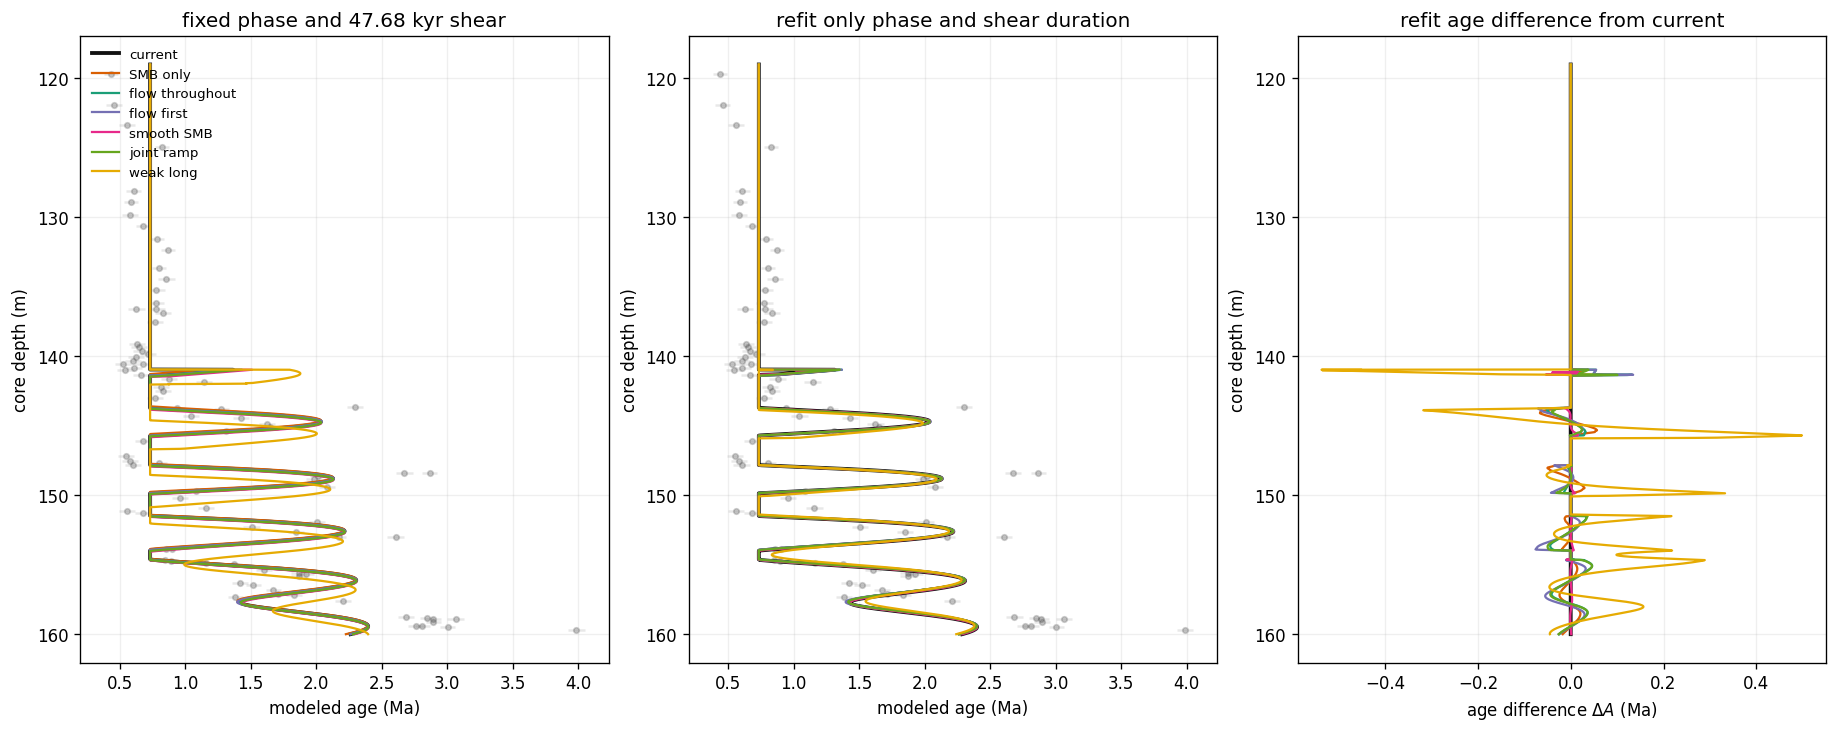

| History | Refit shear (kyr) | RMS (Ma) | Fold peaks (m) | Boundary contacts (m) | Surface / post shear strain |
|---|---:|---:|---|---|---:|
| current | 47.45 | 0.413 | 144.70, 148.80, 152.62 | 140.95, 141.33, 143.69, 145.69, 147.83, 149.84, 151.48, 154.00, 154.62 | 0 / 13.69 |
| SMB only | 47.69 | 0.412 | 144.74, 148.82, 152.62 | 140.95, 141.39, 143.71, 145.69, 147.84, 149.86, 151.48, 153.98, 154.62 | 0 / 13.76 |
| flow throughout | 47.70 | 0.412 | 144.72, 148.80, 152.60 | 140.95, 141.36, 143.72, 145.71, 147.83, 149.84, 151.47, 153.96, 154.59 | 2.92e-05 / 13.76 |
| flow first | 47.70 | 0.413 | 144.72, 148.80, 152.60 | 140.95, 141.36, 143.72, 145.71, 147.84, 149.83, 151.48, 153.91, 154.65 | 0.00149 / 13.76 |
| smooth SMB | 47.45 | 0.413 | 144.70, 148.80, 152.62 | 140.95, 141.31, 143.71, 145.71, 147.83, 149.86, 151.48, 154.00, 154.64 | 5.84e-05 / 13.69 |
| joint ramp | 47.70 | 0.412 | 144.72, 148.80, 152.60 | 140.95, 141.38, 143.71, 145.69, 147.83, 149.84, 151.47, 153.95, 154.62 | 2.92e-05 / 13.76 |
| weak long | 48.16 | 0.411 | 144.82, 148.84, 152.60 | 140.95, 141.00, 143.86, 145.89, 147.81, 150.07, 151.37 | 0.000292 / 13.89 |

With all original fit parameters fixed, the largest departure from the current initialization is **1.291 Ma** for **weak long**. After refitting only phase and shear duration, the largest curve departure is **0.537 Ma**. The joint-ramp time-step check changes age by at most **3.98e-03 Ma**; the combined factor-two surface/slab mesh check changes it by at most **6.26e-03 Ma**. Boundary-supplied material retains the fixed **0.733 Ma** limiting age. Its first supply occurs at each schedule's SMB onset (0 yr except the 10 kyr flow-first control); the model does not assign an absolute calendar age to that dynamical event.

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15.2, 6.0), constrained_layout=True)
for axis in axes[:2]:
    axis.errorbar(age, depth, xerr=relative_error, fmt="o", ms=3.3, alpha=0.25,
                  color="0.25", ecolor="0.65", zorder=1)
for history, fixed_curve, refit_curve in zip(histories, fixed_curves, refit_curves):
    linewidth = 2.3 if history["short"] == "current" else 1.35
    axes[0].plot(fixed_curve, fine_curve_depth, color=history["color"],
                 lw=linewidth, label=history["short"])
    axes[1].plot(refit_curve, fine_curve_depth, color=history["color"], lw=linewidth)
    axes[2].plot(refit_curve - refit_curves[0], fine_curve_depth,
                 color=history["color"], lw=linewidth, label=history["short"])
axes[0].set_title("fixed phase and 47.68 kyr shear")
axes[1].set_title("refit only phase and shear duration")
axes[2].set_title("refit age difference from current")
for axis in axes:
    axis.invert_yaxis()
    axis.set_ylabel("core depth (m)")
axes[0].set_xlabel("modeled age (Ma)")
axes[1].set_xlabel("modeled age (Ma)")
axes[2].set_xlabel(r"age difference $\Delta A$ (Ma)")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
plt.show()

table = [
    "| History | Refit shear (kyr) | RMS (Ma) | Fold peaks (m) | Boundary contacts (m) | Surface / post shear strain |",
    "|---|---:|---:|---|---|---:|",
]
for metric in metrics:
    peak_text = ", ".join(f"{value:.2f}" for value in metric["peaks"]) or "none"
    contact_text = ", ".join(f"{value:.2f}" for value in metric["contacts"]) or "none"
    table.append(
        f"| {metric['history']['short']} | {metric['shear']:.2f} | {metric['rmse']:.3f} | "
        f"{peak_text} | {contact_text} | {metric['surface_shear']:.3g} / {metric['post_shear']:.2f} |"
    )
display(Markdown("\n".join(table)))

fixed_departures = [
    np.max(np.abs(curve - fixed_curves[0])) for curve in fixed_curves[1:]
]
refit_departures = [
    np.max(np.abs(curve - refit_curves[0])) for curve in refit_curves[1:]
]
largest_fixed_index = 1 + int(np.argmax(fixed_departures))
display(Markdown(
    f"With all original fit parameters fixed, the largest departure from the current "
    f"initialization is **{max(fixed_departures):.3f} Ma** for "
    f"**{histories[largest_fixed_index]['short']}**. After refitting only phase and shear "
    f"duration, the largest curve departure is **{max(refit_departures):.3f} Ma**. "
    f"The joint-ramp time-step check changes age by at most **{time_step_difference:.2e} Ma**; "
    f"the combined factor-two surface/slab mesh check changes it by at most "
    f"**{mesh_difference:.2e} Ma**. Boundary-supplied material retains the fixed "
    f"**{FIXED_YOUNG_AGE:.3f} Ma** limiting age. Its first supply occurs at each schedule's "
    f"SMB onset (0 yr except the 10 kyr flow-first control); the model does not assign an "
    f"absolute calendar age to that dynamical event."
))

## Interpretation and limit of this test

This experiment isolates onset order without reopening the successful seven-parameter inverse problem. Any differences arise from noncommuting particle advection during seed formation; they cannot be attributed to retuning the age law, packet thickness, shortening, or SMB impulse. The phase/shear-only comparison asks whether a timing change can be absorbed by the two most direct kinematic nuisance parameters.

The prescribed reflection and translation from the surface to the basal packet remains the largest idealization. A materially stronger initialization study would require a full-Stokes geometry with vertical emergence or burial flow that operates while SMB creates and transports the packet. That is a distinct model, not an innocuous extension of this timing experiment.